# Week 10 Lab: Multimodal generative AI applications

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 2, 3, 4

You will build and **evaluate** a set of multimodal generative tasks with open models:

1. **Image → text:** captioning and visual question answering with a vision-language model (VLM).
2. **Cross-modal reasoning over charts and documents**, scored against ground truth; a **multimodal hallucination** probe.
3. **Text → image** and **image → image** with a distilled diffusion model, scored with CLIP.
4. **Text → speech → text:** synthesise speech, transcribe it back, and measure word error rate.
5. **Provenance:** label AI-generated media and see why metadata alone is fragile.

**Runtime:** Colab → **T4 GPU** recommended (all parts ≈ 15 min). CPU works with smaller models, more slowly.

**Licences:** SD-Turbo is a research release (commercial use needs Stability AI's licence); MMS-TTS is CC BY-NC 4.0 (non-commercial). Both are fine for this lab, not for commercial products.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Before running: choose the input-to-output route

This notebook contains several model pipelines. A **VLM** reads images and
questions to generate text. Diffusion creates or edits images. **TTS** turns
words into speech; **ASR** turns speech back into words.

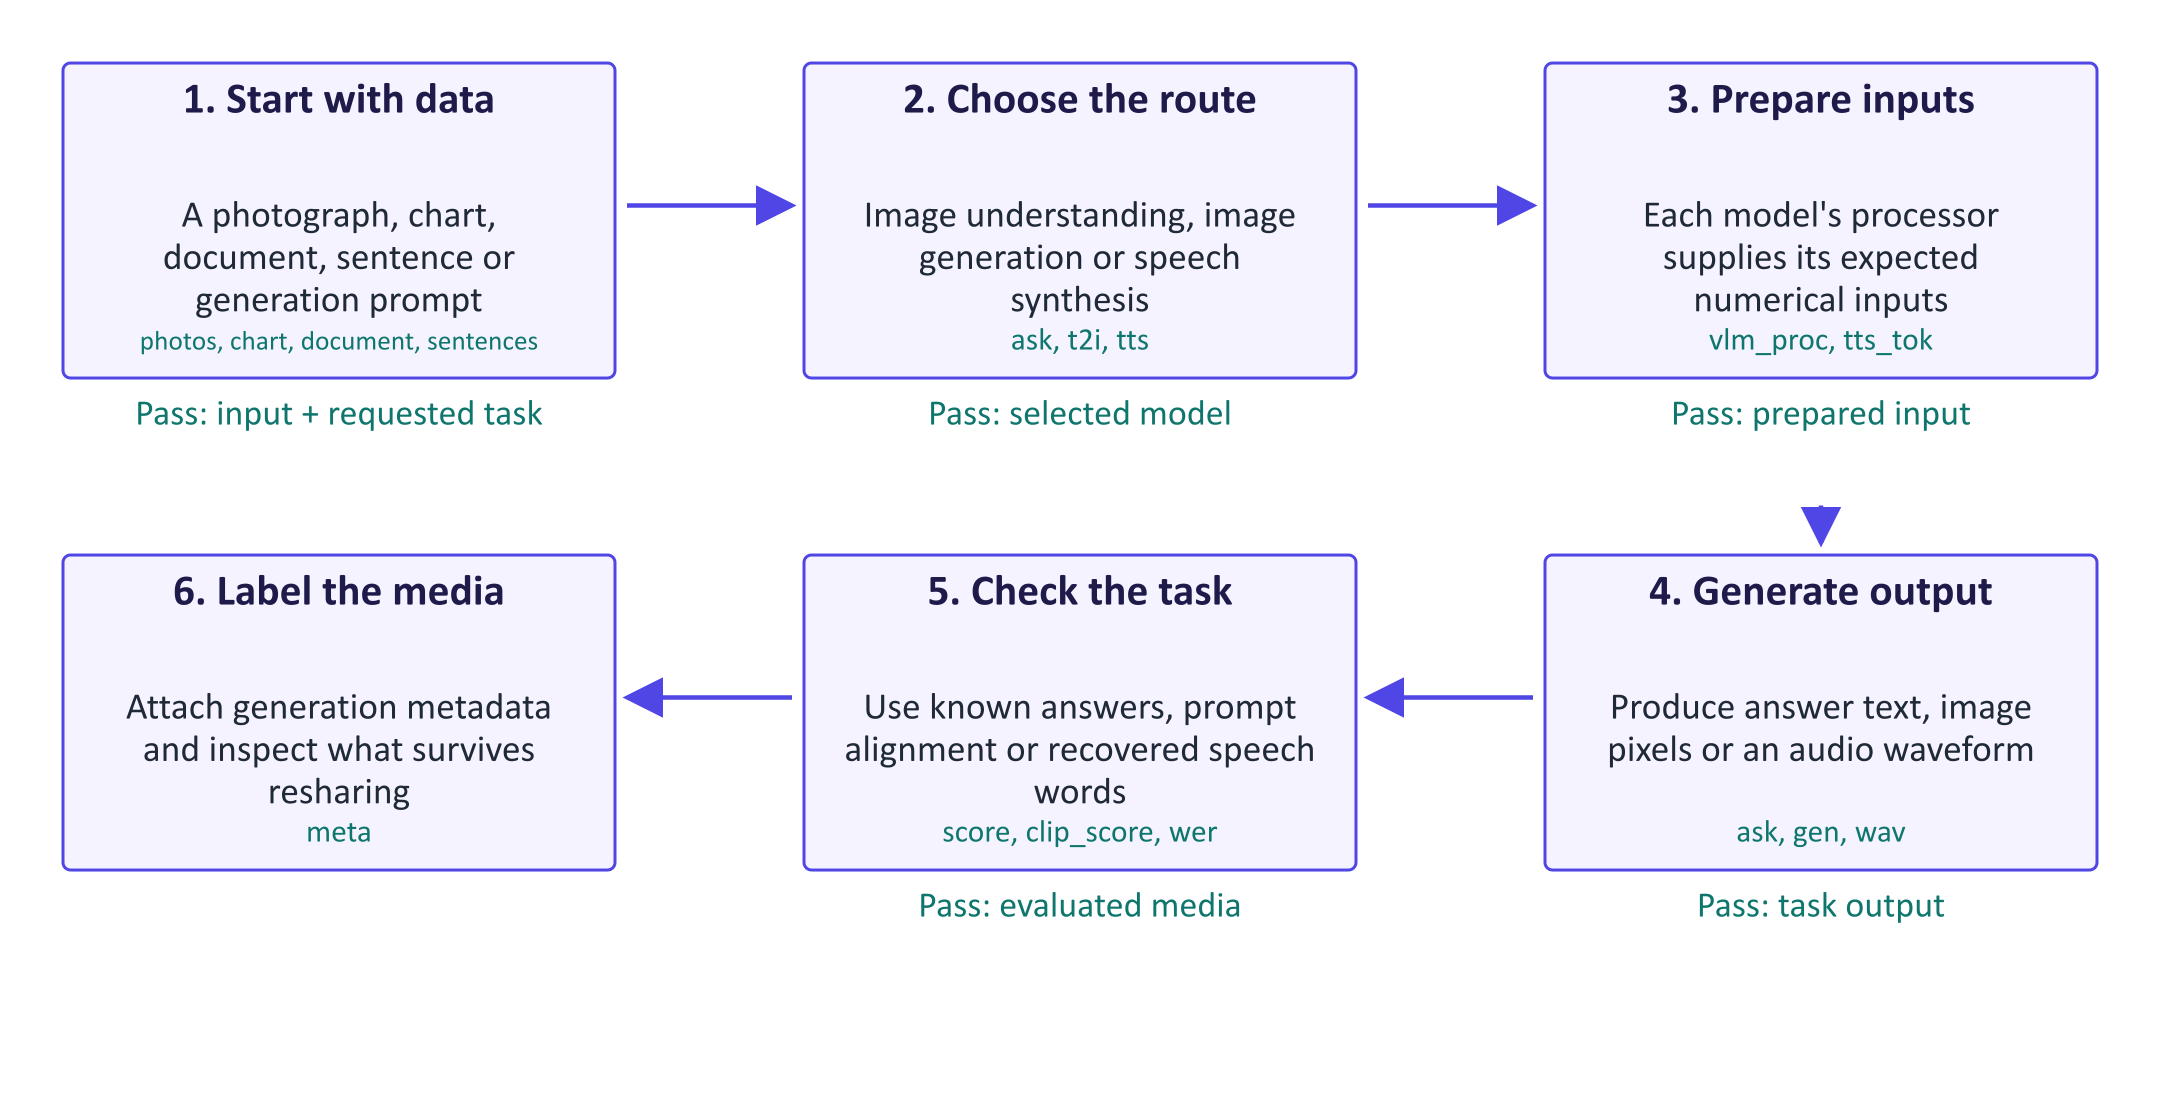

A metric is a measurement for a particular question. A correct chart answer,
image-prompt alignment and speech intelligibility need different checks.

## Lab route and code map

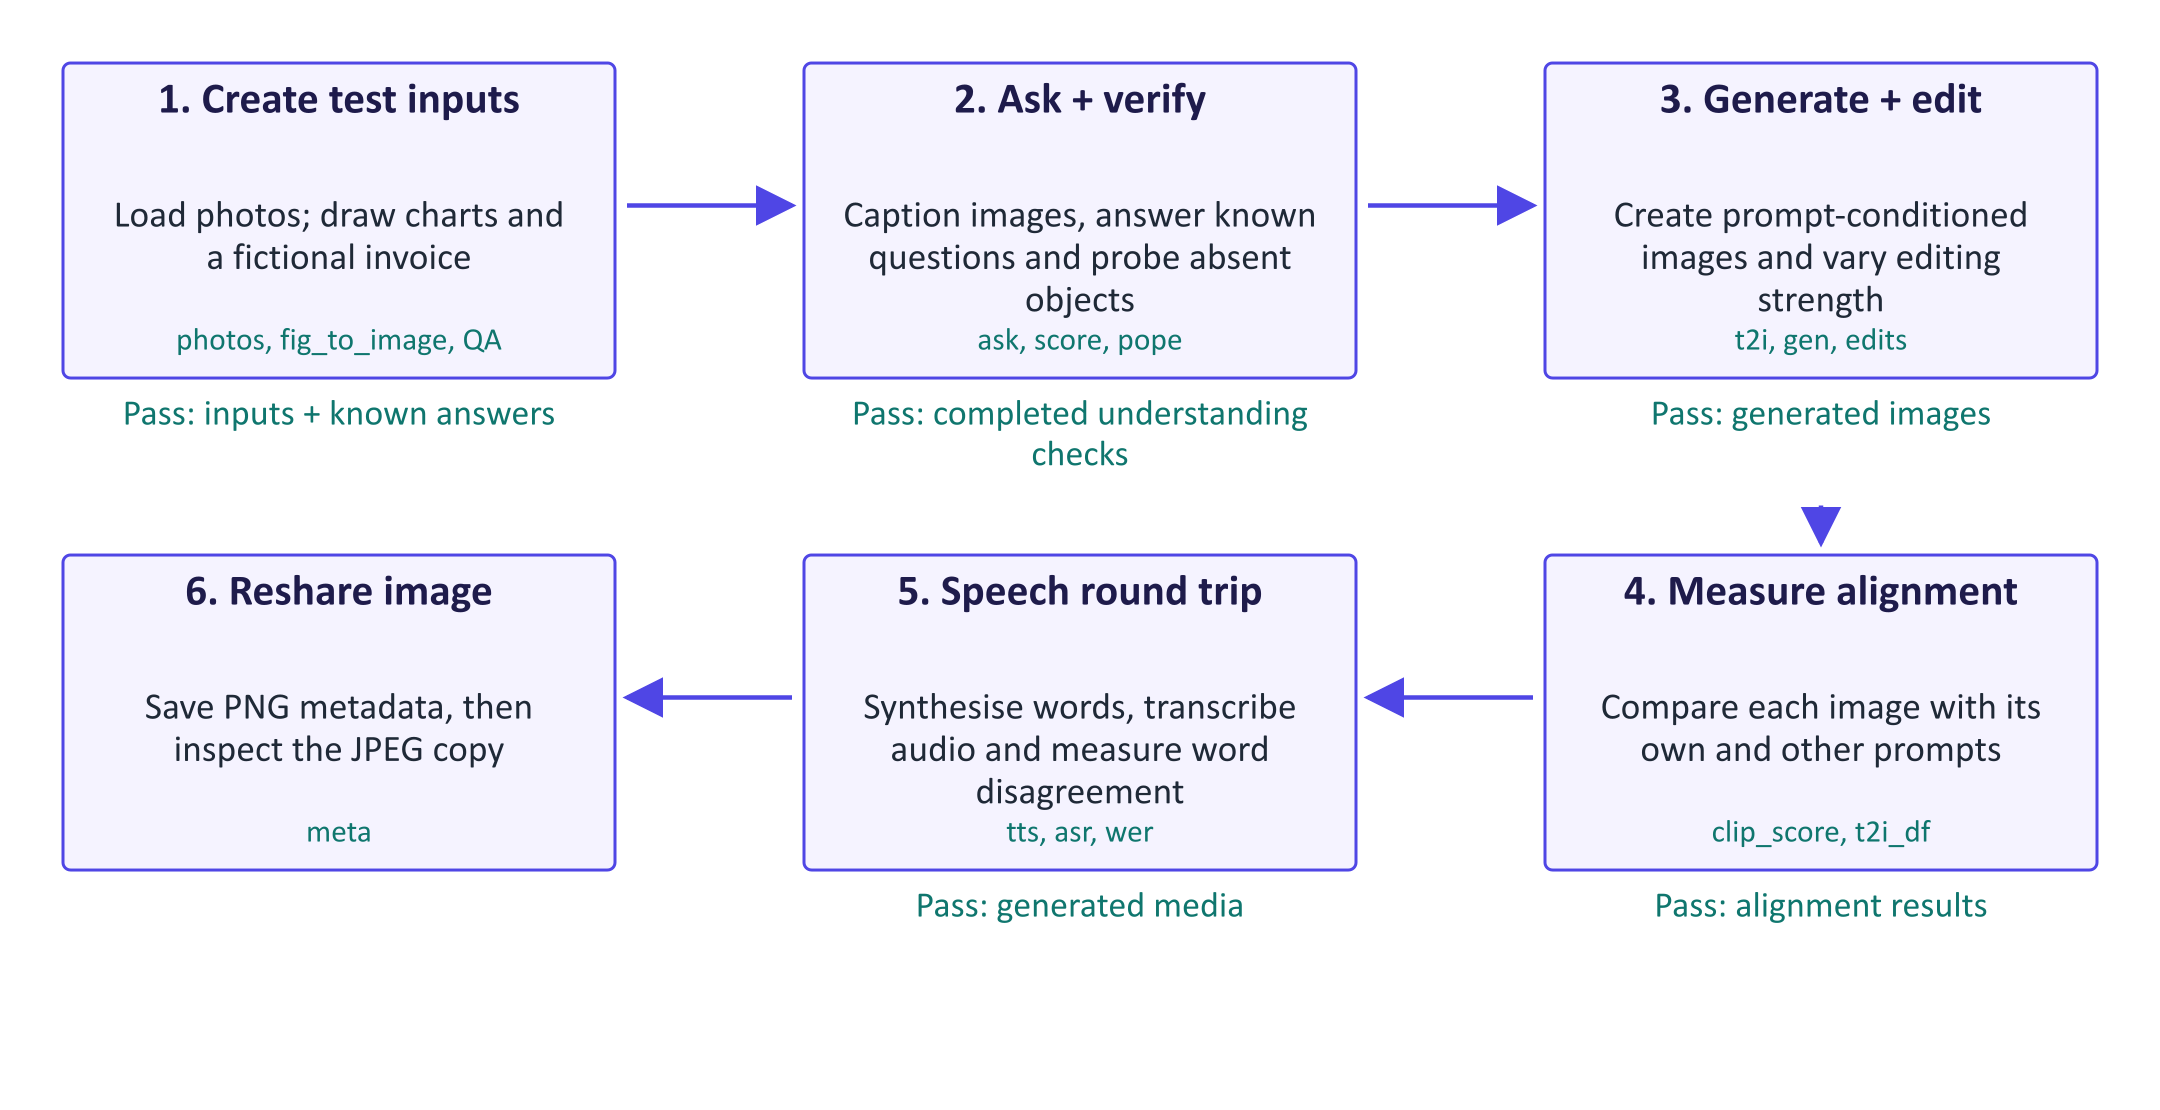

| Diagram block | Code to find | Inspect before continuing |
|---|---|---|
| Create test inputs | `photos`, `fig_to_image`, `QA` | Known chart values and invoice fields. |
| Ask + verify | `ask`, `score`, `pope` | Full answers beside known evidence. |
| Generate + edit | `t2i`, `gen`, `edits` | Prompt, image and editing strength together. |
| Measure alignment | `clip_score`, `t2i_df` | Own-prompt and other-prompt comparisons. |
| Speech round trip | `tts`, `asr`, `wer` | Original words, transcript and audio. |
| Reshare image | `meta` | PNG labels before and after JPEG conversion. |

Automatic scores are partial checks. Inspect each output and its reference
before deciding that the pipeline succeeded.

In [ ]:
%pip install -q transformers diffusers accelerate soundfile pandas matplotlib

In [ ]:
import io
import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from PIL import Image, PngImagePlugin

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
torch.manual_seed(0)
VLM_ID = os.environ.get("GENAI_VLM") or ("HuggingFaceTB/SmolVLM-256M-Instruct" if (SMOKE or DEVICE == "cpu") else "Qwen/Qwen3-VL-2B-Instruct")
print("device:", DEVICE, "| VLM:", VLM_ID)


def fig_to_image(fig, dpi=100):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return Image.open(buf).convert("RGB")

## Part 1 · Image → text with a vision-language model

A VLM is a vision encoder + projector + LLM (week 9). We ask it to describe images and answer questions.

In [ ]:
from sklearn.datasets import load_sample_image
from transformers import AutoModelForImageTextToText, AutoProcessor

vlm_proc = AutoProcessor.from_pretrained(VLM_ID)
vlm = AutoModelForImageTextToText.from_pretrained(VLM_ID, dtype=DTYPE).to(DEVICE).eval()


def ask(image, question, max_new_tokens=60):
    # The placeholder in the chat message identifies where image data belongs.
    msgs = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    prompt = vlm_proc.apply_chat_template(msgs, add_generation_prompt=True)
    inputs = vlm_proc(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=16 if SMOKE else max_new_tokens, do_sample=False)
    # Generation returns the input prefix too; decode only the new answer.
    return vlm_proc.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()


photos = {"temple": Image.fromarray(load_sample_image("china.jpg")), "flower": Image.fromarray(load_sample_image("flower.jpg"))}
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for a, (k, im) in zip(ax, photos.items()):
    a.imshow(im); a.axis("off"); a.set_title(k)
plt.show()  # CAPTION_FIGURE
for k, im in photos.items():
    print(f"{k}: {ask(im, 'Describe this image in one sentence.')}")

## Part 2 · Cross-modal reasoning over charts and documents

We **generate** a chart and a document image ourselves, so we know the correct answers exactly.

In [ ]:
days, tickets = ["Mon", "Tue", "Wed", "Thu", "Fri"], [12, 30, 18, 25, 9]
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar(days, tickets, color="tab:blue"); ax.set_title("Help-desk tickets per day"); ax.set_ylabel("tickets")
chart = fig_to_image(fig)

fig, ax = plt.subplots(figsize=(5, 3.6)); ax.axis("off")
doc_lines = ["INVOICE  No. 2027-0415", "Date: 3 March 2027", "Customer: Dublin Robotics Ltd", "",
             "GPU hours (T4)      40 x 0.50 EUR   20.00", "Storage (TB-month)   2 x 7.50 EUR   15.00", "",
             "TOTAL DUE                         35.00 EUR", "Payment due within 30 days"]
for i, line in enumerate(doc_lines):
    ax.text(0.02, 0.95 - i * 0.1, line, family="monospace", fontsize=11, va="top")
document = fig_to_image(fig)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].imshow(chart); ax[0].axis("off"); ax[1].imshow(document); ax[1].axis("off")
plt.show()  # CHART_FIGURE

QA = [
    (chart, "Which day had the most tickets? Answer with the day only.", "tue"),
    (chart, "How many tickets were there on Thursday? Answer with a number.", "25"),
    (chart, "What is the total number of tickets from Monday to Friday? Answer with a number.", "94"),
    (document, "What is the invoice number? Answer with the number only.", "2027-0415"),
    (document, "What is the total due in EUR? Answer with the number only.", "35"),
    (document, "Who is the customer? Answer with the name only.", "dublin robotics"),
]

**TODO 1:** complete `score(answer, gold)`: normalise the answer (lower-case, remove commas) and return 1 if the gold string appears in it (for numbers, compare the first number found, e.g. "35.00" counts for "35").

This is a deliberately small checking heuristic. A matching substring can
occur in a wrong sentence, and the first number can be unrelated to the
requested field. Read the model answer beside the chart or invoice too.

In [ ]:
def score(answer, gold):
    a = answer.lower().replace(",", "")
    if re.fullmatch(r"[\d.]+", gold):
        nums = re.findall(r"\d+(?:\.\d+)?", a)
        return int(bool(nums) and abs(float(nums[0]) - float(gold)) < 1e-6)
    return int(gold in a)


rows = []
for im, q, gold in (QA[:2] if SMOKE else QA):
    t0 = time.time()
    ans = ask(im, q, max_new_tokens=20)
    rows.append({"question": q[:55], "gold": gold, "answer": ans[:40], "correct": score(ans, gold), "seconds": round(time.time() - t0, 1)})
qa_df = pd.DataFrame(rows)
print("accuracy:", qa_df.correct.mean())
qa_df

### Multimodal hallucination probe (POPE-style)
Ask yes/no questions about objects that **are** and **are not** in the image. A reliable model says "no" for absent objects.

In [ ]:
probes = [(photos["flower"], "Is there a flower in the image? Answer yes or no.", "yes"),
          (photos["flower"], "Is there a dog in the image? Answer yes or no.", "no"),
          (photos["temple"], "Is there a building in the image? Answer yes or no.", "yes"),
          (photos["temple"], "Is there a car in the image? Answer yes or no.", "no"),
          (chart, "Does the chart show data for Saturday? Answer yes or no.", "no"),
          (document, "Does the invoice mention VAT? Answer yes or no.", "no")]
pope = pd.DataFrame([{"question": q, "gold": g, "answer": ask(im, q, 5)[:10]} for im, q, g in (probes[:2] if SMOKE else probes)])
pope["correct"] = [int(a.lower().startswith(g)) for a, g in zip(pope.answer, pope.gold)]
pope

✍️ **Question 1.** How accurate was the VLM on charts and documents? Which questions failed: reading, counting/arithmetic, or hallucination? What would you change before using such a model to process invoices?

**✅ Model answer:**
Strong small VLMs (e.g. Qwen3-VL-2B) usually read single values and text fields correctly but are less reliable at aggregation (summing the chart) and can say "yes" to absent objects or unmentioned fields (hallucination), while tiny models (SmolVLM-256M) often read labels but miss numbers. Failures cluster into: OCR/reading errors (small fonts, low resolution), arithmetic (the model estimates rather than computes), and hallucination under leading questions. Before processing invoices: ask the model to extract fields into a validated schema (week 7) and compute totals in code; check extracted totals against line items; use higher resolution or a document-specialised model; build a labelled test set of real invoices and measure field-level accuracy; keep a human review step for low-confidence or high-value cases; and remember that "valid JSON" does not mean correct values.

## Part 3 · Text → image and image → image

**SD-Turbo** is a distilled diffusion model (week 4) that generates in 1–4 steps without classifier-free guidance.

In [ ]:
from diffusers import AutoPipelineForImage2Image, AutoPipelineForText2Image

if SMOKE:
    t2i = AutoPipelineForText2Image.from_pretrained("hf-internal-testing/tiny-sd-pipe", safety_checker=None).to(DEVICE)
    SIZE, STEPS = 64, 2
else:
    t2i = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=DTYPE).to(DEVICE)
    SIZE, STEPS = 512, 2
t2i.set_progress_bar_config(disable=True)
prompts = ["a watercolour painting of a lighthouse at sunset",
           "a robot reading a book in a library, digital art",
           "a bowl of ramen on a wooden table, photograph"]
gen = [t2i(p, num_inference_steps=STEPS, guidance_scale=0.0, height=SIZE, width=SIZE,
           generator=torch.Generator("cpu").manual_seed(i)).images[0] for i, p in enumerate(prompts)]
fig, ax = plt.subplots(1, 3, figsize=(12, 4.3))
for a, im, p in zip(ax, gen, prompts):
    a.imshow(im); a.axis("off"); a.set_title(p[:32] + "…", fontsize=9)
plt.show()  # T2I_FIGURE

**TODO 2:** image → image. Use the same model as an img2img pipeline (`AutoPipelineForImage2Image.from_pipe(t2i)`) to restyle the lighthouse image with the prompt "the same scene as a pencil sketch" at `strength` 0.3, 0.6 and 0.9 (with `num_inference_steps=4`; the effective steps are `steps × strength`).

Image-to-image perturbs the input representation before denoising it with
the new prompt. Compare how much of the original scene survives each
strength. The low step count also makes the effective schedule discrete.

In [ ]:
i2i = AutoPipelineForImage2Image.from_pipe(t2i)
edits = [i2i("the same scene as a pencil sketch", image=gen[0], strength=s, num_inference_steps=4, guidance_scale=0.0,
             generator=torch.Generator("cpu").manual_seed(0)).images[0] for s in (0.3, 0.6, 0.9)]
fig, ax = plt.subplots(1, 4, figsize=(14, 3.8))
for a, im, t in zip(ax, [gen[0]] + edits, ["original", "strength 0.3", "strength 0.6", "strength 0.9"]):
    a.imshow(im); a.axis("off"); a.set_title(t)
plt.show()  # I2I_FIGURE

### Evaluate prompt alignment with CLIP score (from weeks 4 and 9)
A score compares image and text embeddings. It does not verify every object,
the absence of artefacts or the correctness of written numbers in the image.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
cproc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


@torch.no_grad()
def clip_score(image, text):
    inp = cproc(text=[text], images=image, return_tensors="pt", padding=True).to(DEVICE)
    o = clip(**inp)
    return 100 * torch.nn.functional.cosine_similarity(o.image_embeds, o.text_embeds).item()


rows = [{"prompt": p[:40], "CLIP score (own prompt)": round(clip_score(im, p), 1),
         "CLIP score (other prompts, mean)": round(np.mean([clip_score(im, q) for q in prompts if q != p]), 1)} for im, p in zip(gen, prompts)]
t2i_df = pd.DataFrame(rows)
t2i_df

## Part 4 · Text → speech → text

**TODO 3:** synthesise speech with MMS-TTS (`facebook/mms-tts-eng`, a VITS model), transcribe it with Whisper, and compute the word error rate against the original text (reuse the WER function from week 9, provided below).

Keep the waveform's sampling rate attached when passing it to ASR. WER
measures word disagreement after normalisation; listen to the generated
audio as well, because recovered words do not measure voice naturalness.

In [ ]:
from transformers import AutoTokenizer, VitsModel, pipeline

tts_tok = AutoTokenizer.from_pretrained("facebook/mms-tts-eng")
tts = VitsModel.from_pretrained("facebook/mms-tts-eng").to(DEVICE).eval()
asr = pipeline("automatic-speech-recognition", model="openai/whisper-tiny" if SMOKE else "openai/whisper-base", device=0 if DEVICE == "cuda" else -1)


def wer(ref, hyp):
    r, h = re.sub(r"[^\w\s]", "", ref.lower()).split(), re.sub(r"[^\w\s]", "", hyp.lower()).split()
    d = np.zeros((len(r) + 1, len(h) + 1), dtype=int)
    d[:, 0], d[0, :] = range(len(r) + 1), range(len(h) + 1)
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            d[i, j] = min(d[i - 1, j] + 1, d[i, j - 1] + 1, d[i - 1, j - 1] + (r[i - 1] != h[j - 1]))
    return d[-1, -1] / max(1, len(r))


sentences = ["The lab opens at nine in the morning.", "Generative models can create images, text and speech.",
             "Please submit your project report by the fifteenth of March."]
rows = []
for s in (sentences[:1] if SMOKE else sentences):
    with torch.no_grad():
        wav = tts(**tts_tok(s, return_tensors="pt").to(DEVICE)).waveform[0].float().cpu().numpy()
    sr = tts.config.sampling_rate
    hyp = asr({"raw": wav, "sampling_rate": sr})["text"].strip()
    rows.append({"text": s, "transcript": hyp, "WER": round(wer(s, hyp), 3), "seconds of audio": round(len(wav) / sr, 1)})
sf.write("tts_example.wav", wav, sr)
speech_df = pd.DataFrame(rows)
speech_df

✍️ **Question 2.** What does the TTS → ASR round trip measure, and what does it not measure? How would you evaluate a voice assistant's speech output properly?

**✅ Model answer:**
The round trip measures intelligibility as judged by one ASR model: low WER means Whisper recovered the words, a cheap automatic proxy. It does not measure naturalness, prosody, emotion, speaker similarity, pronunciation of names, latency or whether a human listener finds it pleasant; errors can also cancel out (the ASR may "fix" a mispronunciation it expects). Proper evaluation adds human listening tests (Mean Opinion Score for naturalness, intelligibility tests with real listeners), checks on hard content (numbers, dates, names, other languages and accents), latency measurements for real-time use, and safety checks (consent for any cloned voice, disclosure that the voice is synthetic).

## Part 5 · Provenance: labelling AI-generated media

**TODO 4:** save the first generated image as PNG with metadata fields `ai_generated=true`, `model=stabilityai/sd-turbo` and `prompt=...`, then reload it and print the metadata. Then show how easily the label is lost by re-saving as JPEG.
The metadata is a text label, not an authenticated proof of origin. In smoke
mode the tiny test pipeline is used, so the requested model field below is
only the classroom example label and does not identify that test pipeline.

In [ ]:
meta = PngImagePlugin.PngInfo()
meta.add_text("ai_generated", "true")
meta.add_text("model", "stabilityai/sd-turbo")
meta.add_text("prompt", prompts[0])
gen[0].save("generated.png", pnginfo=meta)
print("PNG metadata:", Image.open("generated.png").text)
Image.open("generated.png").convert("RGB").save("reshared.jpg", quality=90)
print("after re-saving as JPEG:", getattr(Image.open("reshared.jpg"), "text", {}) or "no text metadata left")

✍️ **Question 3.** Why is metadata labelling insufficient on its own? Compare C2PA content credentials and invisible watermarks (e.g. SynthID), and state what the EU AI Act (Article 50) requires.

**✅ Model answer:**
Metadata is easily stripped, intentionally or by ordinary processing (re-saving, screenshots, social-media uploads), and can be forged, so it only helps when the chain of custody is intact. C2PA content credentials cryptographically sign provenance information (who created or edited an asset, with which tools), so tampering is detectable, but they can still be removed and many platforms do not display them. Invisible watermarks such as Google DeepMind's SynthID are embedded in the pixels (or audio/text) and survive common edits, allowing detection by the provider's detector, but they are not universal, can be weakened by heavy edits and only exist if the generator adds them. Detection classifiers are an arms race. Under Article 50 of the EU AI Act (applying from 2 August 2026), providers of generative AI must mark outputs in a machine-readable way and deployers must disclose deepfakes and AI-generated text published to inform the public; systems already on the market have until 2 December 2026 for the marking obligation. Robust practice combines credentials, watermarks, visible labels and platform policies.

In [ ]:
# Instructor tooling: save measured results for the lecture slides (only when requested).
if os.environ.get("GENAI_RESULTS_PATH"):
    import json
    payload = {"vlm": VLM_ID, "device": DEVICE, "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU",
               "qa": qa_df.to_dict("records"), "qa_accuracy": float(qa_df.correct.mean()),
               "pope": pope.to_dict("records"), "pope_accuracy": float(pope.correct.mean()),
               "t2i": t2i_df.to_dict("records"), "speech": speech_df.to_dict("records"),
               "captions": {k: ask(im, "Describe this image in one sentence.") for k, im in photos.items()}}
    with open(os.environ["GENAI_RESULTS_PATH"], "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=float)
    print("results saved")